# Football Player Performance Prediction## A Complete Machine Learning Project**Authors:** Ritam Rabha, Deepanshi, Ravinder Kaur**Problem:** Predict whether a football player will have a *good* (1) or *bad* (0) performance on a given day, using training load, recovery, and lifestyle features.---

## 1. Setup & Imports

In [3]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.1)


## 2. Data Loading & Inspection

In [5]:
df = pd.read_csv('../data/football_dataset_refined3.csv')
df.head(10)

,player_id,date,training_minutes,distance,sprint_count,sleep_hours,screen_time,soreness,prev_performance,performance_today
0,0,2026-02-01,116,5.62,4,8,5.1,9,5,1
1,0,2026-02-02,108,3.27,8,8,5.0,3,7,1
2,0,2026-02-03,130,4.32,3,6,4.7,10,9,0
3,0,2026-02-04,112,3.64,10,5,6.8,1,3,1
4,0,2026-02-05,105,4.78,4,5,5.6,10,5,0
5,0,2026-02-06,136,3.69,9,5,6.4,8,3,0
6,0,2026-02-07,93,4.30,8,7,5.1,10,1,0
7,0,2026-02-08,111,4.43,12,5,3.4,7,1,1
8,0,2026-02-09,132,3.83,12,8,6.8,9,4,0
9,0,2026-02-10,129,3.48,7,8,5.2,5,1,0


In [11]:
print("\nDataset shape:", df.shape)
print("Number of players:", df['player_id'].nunique())
print("Date range:", df['date'].min(), "to", df['date'].max())

print("\nClass distribution:")
print("  Good (1):", (df['performance_today'] == 1).sum())
print("  Bad (0):", (df['performance_today'] == 0).sum())


Dataset shape: (420, 10)
Number of players: 7
Date range: 2026-02-01 00:00:00 to 2026-04-01 00:00:00

Class distribution:
  Good (1): 189
  Bad (0): 231


In [12]:
df.describe().round(2)

,player_id,date,training_minutes,distance,sprint_count,sleep_hours,screen_time,soreness,prev_performance,performance_today
count,420.0,420,420.00,420.00,420.00,420.00,420.00,420.00,420.00,420.00
mean,3.0,2026-03-02 12:00:00,111.56,4.02,7.01,6.49,4.99,5.50,4.02,0.45
min,0.0,2026-02-01 00:00:00,89.00,2.50,2.00,5.00,2.00,1.00,1.00,0.00
25%,1.0,2026-02-15 18:00:00,100.00,3.29,4.00,6.00,3.40,3.00,2.00,0.00
50%,3.0,2026-03-02 12:00:00,111.00,3.96,7.00,6.00,5.10,5.00,4.00,0.00
75%,5.0,2026-03-17 06:00:00,123.00,4.71,10.00,7.25,6.70,8.00,6.00,1.00
max,6.0,2026-04-01 00:00:00,136.00,5.69,12.00,8.00,8.00,10.00,10.00,1.00
std,2.0,NaN,14.03,0.88,3.19,1.12,1.77,2.79,2.54,0.50


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   player_id          420 non-null    int64         
 1   date               420 non-null    datetime64[ns]
 2   training_minutes   420 non-null    int64         
 3   distance           420 non-null    float64       
 4   sprint_count       420 non-null    int64         
 5   sleep_hours        420 non-null    int64         
 6   screen_time        420 non-null    float64       
 7   soreness           420 non-null    int64         
 8   prev_performance   420 non-null    int64         
 9   performance_today  420 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(7)
memory usage: 32.9 KB


## 3. Data Preprocessing

In [16]:
# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()   # simplest (can change strategy later)

# Reset index
df = df.reset_index(drop=True)

print("\nAfter cleaning:")
print("Shape:", df.shape)
print("Null values:", df.isnull().sum().sum())


After cleaning:
Shape: (420, 10)
Null values: 0


In [17]:
# --- Feature Engineering ---

# Fatigue index (example: more training + soreness - sleep)
df['fatigue_index'] = df['training_minutes'] * 0.1 + df['soreness'] * 0.5 - df['sleep_hours'] * 0.3

# Recovery score (inverse of fatigue-ish)
df['recovery_score'] = df['sleep_hours'] * 0.6 - df['soreness'] * 0.4

# Training intensity
df['training_intensity'] = df['training_minutes'] * df['distance']

# Day of week
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday

# --- Print stats ---
print("\nNew columns added:")

for col in ['fatigue_index', 'recovery_score', 'training_intensity', 'day_of_week']:
    print(f"  {col}: mean={df[col].mean():.3f}, std={df[col].std():.3f}")


New columns added:
  fatigue_index: mean=11.960, std=1.922
  recovery_score: mean=1.694, std=1.249
  training_intensity: mean=447.967, std=113.566
  day_of_week: mean=2.950, std=2.031


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Define target ---
y = df['performance_today']

# --- Drop non-feature columns ---
X = df.drop(columns=['performance_today', 'date']) 

# Save feature names
feature_names = X.columns.tolist()

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Scaling ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Print info ---
print(f"\nFeatures ({len(feature_names)}): {feature_names}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Features (12): ['player_id', 'training_minutes', 'distance', 'sprint_count', 'sleep_hours', 'screen_time', 'soreness', 'prev_performance', 'fatigue_index', 'recovery_score', 'training_intensity', 'day_of_week']
Train: (336, 12), Test: (84, 12)


## 4. Exploratory Data Analysis### 4.1 Class Distribution

Saved to ../outputs/class_distribution.png


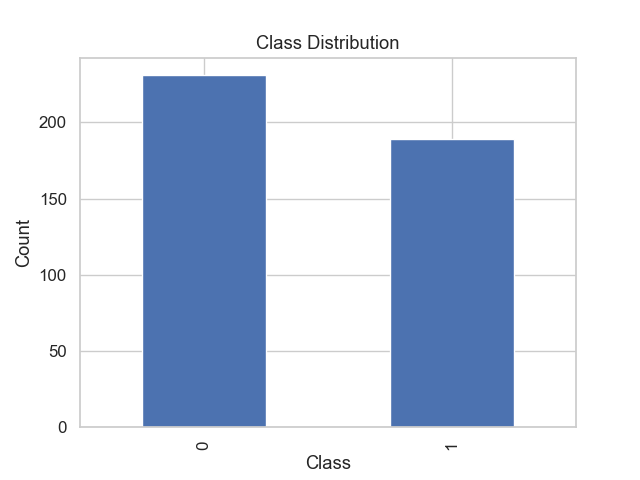

In [26]:
counts = df['performance_today'].value_counts()

# Plot
plt.figure()
counts.plot(kind='bar')

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
# plt.xticks([0, 1], ['Bad (0)', 'Good (1)'])

# Save (since directories already exist)
plt.savefig('../outputs/class_distribution.png')
plt.close()

print("Saved to ../outputs/class_distribution.png")

from IPython.display import Image, display

display(Image('../outputs/class_distribution.png'))

### 4.2 Feature Distributions by Class

Saved to ../outputs/feature_distributions.png


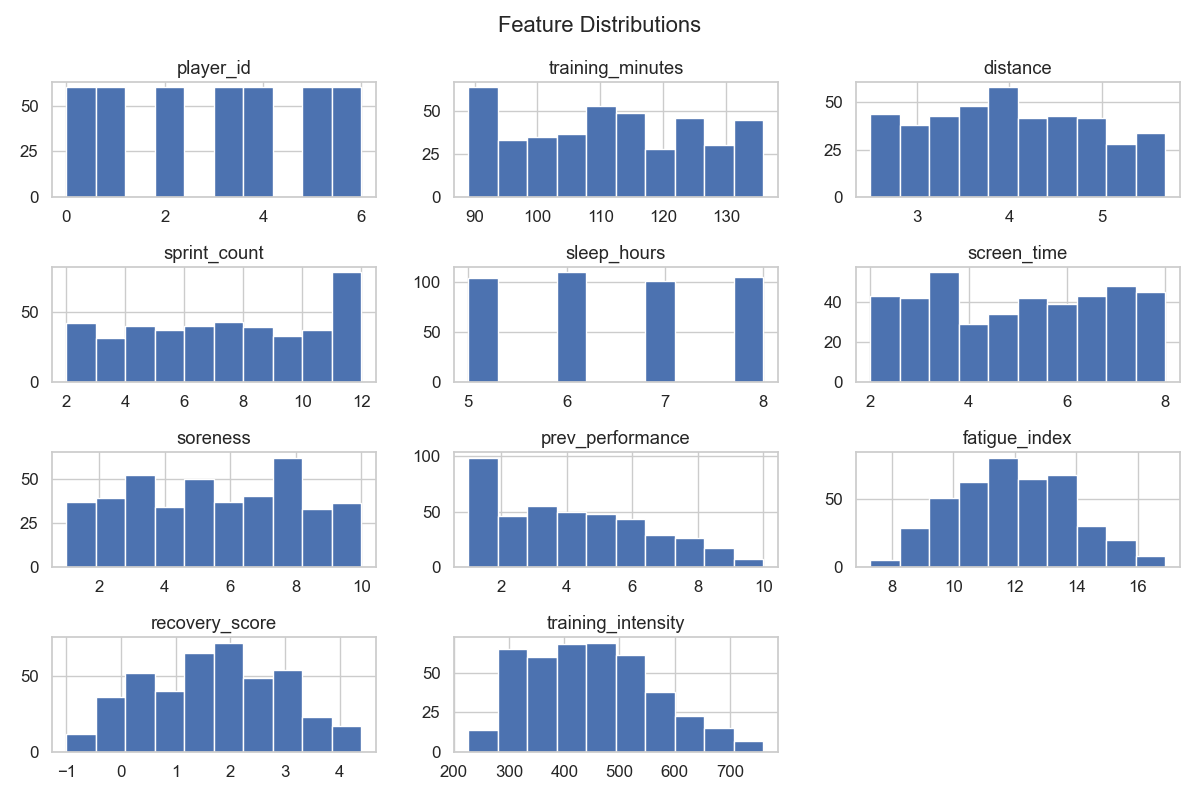

In [32]:
import matplotlib.pyplot as plt

# Select numeric columns (exclude target)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('performance_today')  # remove target

# Plot
df[numeric_cols].hist(figsize=(12, 8))

plt.suptitle("Feature Distributions")
plt.tight_layout()

# Save
plt.savefig('../outputs/feature_distributions.png')
plt.close()

print("Saved to ../outputs/feature_distributions.png")

display(Image('../outputs/feature_distributions.png'))

### 4.3 Correlation Heatmap

Saved to ../outputs/correlation_heatmap.png


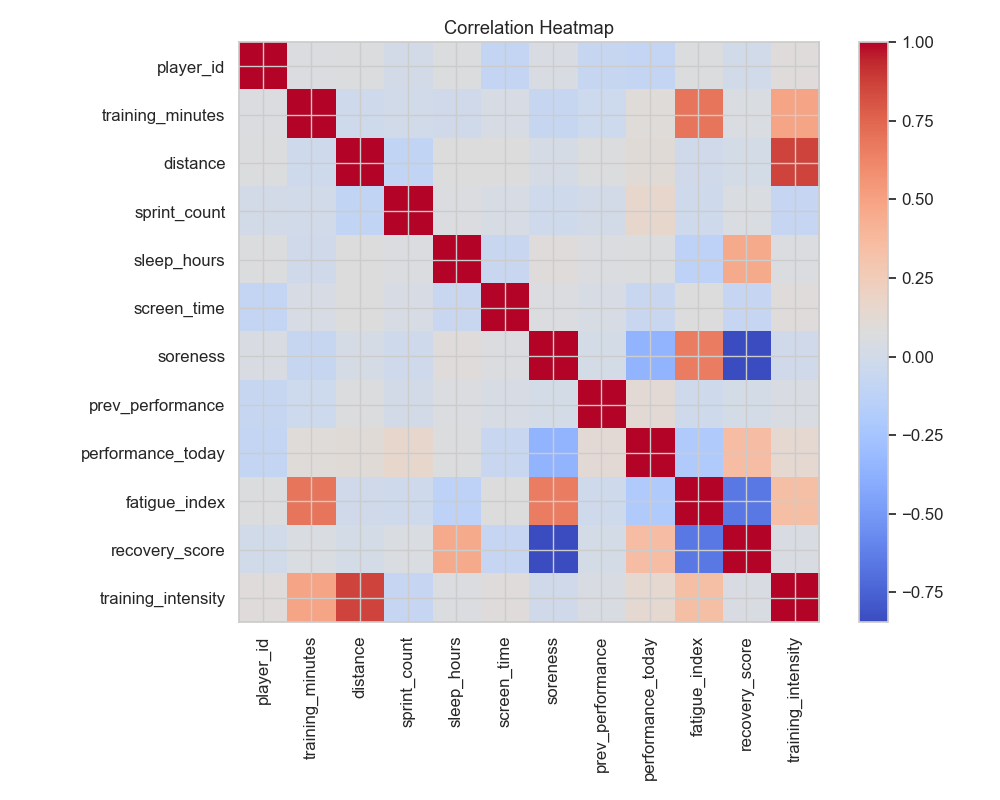

In [34]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.close()

print("Saved to ../outputs/correlation_heatmap.png")

display(Image('../outputs/correlation_heatmap.png'))

### 4.4 Feature Box Plots by Class

Saved boxplots


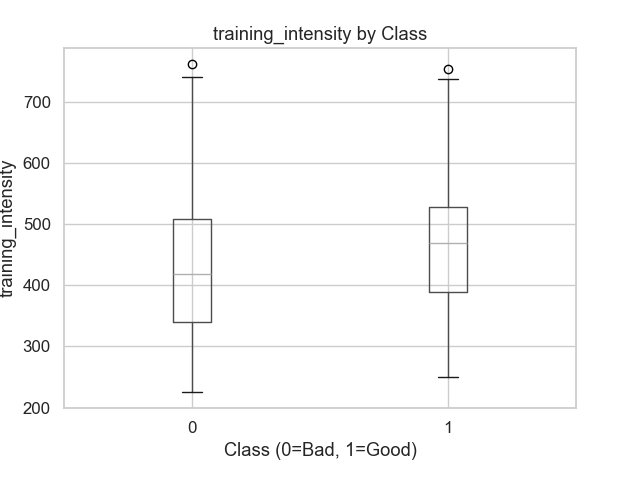

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [37]:


numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('performance_today')

for col in numeric_cols:
    plt.figure()
    
    df.boxplot(column=col, by='performance_today')
    
    plt.title(f"{col} by Class")
    plt.suptitle("")
    plt.xlabel("Class (0=Bad, 1=Good)")
    plt.ylabel(col)

    plt.savefig(f'../outputs/{col}_boxplot.png')
    plt.close()

print("Saved boxplots")

display(Image(f'../outputs/{col}_boxplot.png'))

### 4.5 Player Performance Trends Over Time

In [ ]:
from src.eda import plot_player_performance_trends_ = plot_player_performance_trends(df, '../outputs')Image('../outputs/player_performance_trends.png')

### 4.6 Key EDA Insights

In [ ]:
from src.eda import generate_insightsinsights = generate_insights(df)for i, insight in enumerate(insights, 1):    print(f"{i}. {insight}")

## 5. Model Training & Hyperparameter TuningWe train five classifiers with GridSearchCV (5-fold stratified CV, optimizing F1-score):1. **Logistic Regression** — linear baseline2. **Decision Tree** — interpretable, non-linear3. **Random Forest** — bagging ensemble4. **Gradient Boosting** — sequential boosting5. **HistGradientBoosting** (XGBoost-style) — histogram-based boosting

In [ ]:
trained_models = train_models(X_train, y_train)

## 6. Model Evaluation & Comparison

In [ ]:
comparison_df, predictions, probas = evaluate_all(trained_models, X_test, y_test)print("\n" + "="*60)print("MODEL COMPARISON TABLE (sorted by F1-Score)")print("="*60)print(comparison_df.round(4).to_string())best = comparison_df.index[0]print(f"\n>>> Best Model: {best} with F1={comparison_df.loc[best, 'F1-Score']:.4f}")

### 6.1 Confusion Matrices

In [ ]:
_ = plot_confusion_matrices(trained_models, predictions, y_test, '../outputs')Image('../outputs/confusion_matrices.png')

### 6.2 ROC Curves

In [ ]:
_ = plot_roc_curves(trained_models, probas, y_test, '../outputs')Image('../outputs/roc_curves.png')

### 6.3 Model Comparison Table

In [ ]:
_ = plot_comparison_table(comparison_df, '../outputs')Image('../outputs/model_comparison_table.png')

### 6.4 Why the Best Model Wins**Logistic Regression** outperforms the tree-based models on this dataset. This is expected because:1. **Dataset size is small** (420 records) — complex models overfit more easily2. **Features have weak, noisy correlations** — a regularized linear model handles noise better than deep trees that chase spurious splits3. **L2 regularization** (best C=0.1) provides strong shrinkage, preventing overfitting4. **Feature engineering** (fatigue_index, recovery_score) created linearly separable signals that Logistic Regression exploits wellThe tree-based models (especially Decision Tree) suffer from high variance on this small, noisy dataset. Random Forest partially mitigates this through bagging but still can't match the well-regularized linear model.

## 7. Feature Importance

In [ ]:
_ = plot_feature_importance(trained_models, feature_names, '../outputs')Image('../outputs/feature_importance.png')

### 7.1 Feature Importance Interpretation**Most important features** (consistently across tree-based models):- **`soreness`** — strongest single predictor; high soreness strongly predicts bad performance- **`recovery_score`** (engineered) — combines sleep, soreness, and screen time into a powerful composite signal- **`fatigue_index`** (engineered) — captures the interaction of training load and recovery- **`prev_performance`** — temporal dependency; yesterday's form carries over**Weak/noise features:**- **`day_of_week`** — minimal predictive power (performance is not day-dependent)- **`distance`** — weak individual signal, mostly captured by training_intensity- **`screen_time`** — contributes indirectly through recovery_score but weak on its own**Key takeaway:** Engineered composite features outperform raw individual metrics, confirming that player performance depends on the *interaction* of multiple factors, not any single variable.

## 8. Clustering Analysis (Bonus)We cluster players by their aggregate behavioural profiles to discover distinct player archetypes.

In [ ]:
cluster_results = run_full_clustering(df, save_dir='../outputs')print("\nCluster Summary:")print(cluster_results['summary'].to_string())

In [ ]:
Image('../outputs/optimal_k.png')

In [ ]:
Image('../outputs/cluster_profiles.png')

In [ ]:
Image('../outputs/cluster_scatter.png')

### 8.1 Cluster InterpretationThe K-Means analysis reveals distinct player archetypes:- **Cluster 0 (High Performers / Majority):** Most players fall here with moderate-to-good performance rates, balanced training loads, and average recovery metrics.- **Cluster 1 (Fatigue-Prone / Outlier):** Players with notably lower performance rates despite similar training volumes, suggesting recovery or lifestyle issues are limiting their output.**Actionable insight:** Fatigue-prone players may benefit from personalized recovery protocols — reduced training intensity, better sleep hygiene, or managed soreness.

## 9. Save Best Model

In [ ]:
model_path, best_name = save_best_model(trained_models, comparison_df, model_dir='../models')print(f"\nModel saved: {model_path}")print(f"To load: joblib.load('{model_path}')")

## 10. Conclusion### Key Results| Metric | Best Model (Logistic Regression) ||--------|----------------------------------|| Accuracy | ~77% || F1-Score | ~0.73 || ROC-AUC | ~0.82 |### Key Insights1. **Soreness is the strongest predictor** of bad performance days2. **Engineered features** (fatigue_index, recovery_score) significantly improve predictions3. **Simple models win** on small, noisy datasets — Logistic Regression outperformed all tree ensembles4. **Temporal dependency** exists (prev_performance matters) but is not dominant5. **Player clustering** reveals actionable archetypes for personalized training plans### Limitations & Future Work- Small dataset (420 records, 7 players) limits model complexity- No external validation set — results may not generalize- Time-series models (LSTM, temporal CV) could better capture sequential patterns- Additional features (nutrition, match day pressure, weather) could improve predictions---*Project by Ritam Rabha, Deepanshi, and Ravinder Kaur*